In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 성가신 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path, header='infer'):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc, header=header)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")

# 데이터 불러오기
df_curr = load_csv('지역화폐연령별성별이용현황.csv')
df_pop = load_csv('연령_및_성별_인구_–_읍면동_20260323211811.csv', header=1)

df_pop

,행정구역별(읍면동),연령별,내국인(명),내국인_남자(명),내국인_여자(명)
0,경기도,합계,13233278.0,6645322.0,6587956.0
1,경기도,0~4세,384022.0,196365.0,187657.0
2,경기도,5~9세,538972.0,276352.0,262620.0
3,경기도,10~14세,645745.0,329968.0,315777.0
4,경기도,15~19세,617512.0,316163.0,301349.0
5,경기도,20~24세,663835.0,347888.0,315947.0
6,경기도,25~29세,871011.0,461056.0,409955.0
7,경기도,30~34세,948550.0,503602.0,444948.0
8,경기도,35~39세,882511.0,457813.0,424698.0
9,경기도,40~44세,1091859.0,560822.0,531037.0


In [10]:
# ==========================================
# 2. 전처리: 지역화폐 데이터 (10대 ~ 80대만 추출)
# ==========================================
df_curr_24 = df_curr[df_curr['기준연도'] == 2024].copy()

def map_curr_age(age):
    age = str(age).strip()
    if age in ['10', '10대']: return '10대'
    elif age in ['20', '20대']: return '20대'
    elif age in ['30', '30대']: return '30대'
    elif age in ['40', '40대']: return '40대'
    elif age in ['50', '50대']: return '50대'
    elif age in ['60', '60대']: return '60대'
    elif age in ['70', '70대']: return '70대'
    elif age in ['80', '80대', '80대이상', '80세 이상', '80대 이상', '80이상']: return '80대'
    else: return None # 10대 미만, 90대 이상, 기타, 미분류 등은 모두 제외

df_curr_24['연령대_통합'] = df_curr_24['연령대'].apply(map_curr_age)
df_curr_24 = df_curr_24.dropna(subset=['연령대_통합'])

df_curr_24['결제금액'] = pd.to_numeric(df_curr_24['결제금액'], errors='coerce').fillna(0)
df_curr_24['결제건수'] = pd.to_numeric(df_curr_24['결제건수'], errors='coerce').fillna(0)

curr_grouped = df_curr_24.groupby(['연령대_통합', '성별'])[['결제금액', '결제건수']].sum().reset_index()


# ==========================================
# 3. 전처리: 인구 데이터 (10대 ~ 80대만 추출)
# ==========================================
def map_pop_age(age):
    age = str(age).strip()
    if age in ['10~14세', '15~19세']: return '10대'
    elif age in ['20~24세', '25~29세']: return '20대'
    elif age in ['30~34세', '35~39세']: return '30대'
    elif age in ['40~44세', '45~49세']: return '40대'
    elif age in ['50~54세', '55~59세']: return '50대'
    elif age in ['60~64세', '65~69세']: return '60대'
    elif age in ['70~74세', '75~79세']: return '70대'
    elif age in ['80~84세', '85~89세']: return '80대'
    else: return None

df_pop_gg = df_pop[df_pop['행정구역별(읍면동)'] == '경기도'].copy()
df_pop_gg['연령대_통합'] = df_pop_gg['연령별'].apply(map_pop_age)
df_pop_gg = df_pop_gg.dropna(subset=['연령대_통합'])

pop_grouped = df_pop_gg.groupby('연령대_통합')[['내국인_남자(명)', '내국인_여자(명)']].sum().reset_index()
pop_melted = pop_grouped.melt(id_vars='연령대_통합', var_name='성별', value_name='인구수')
pop_melted['성별'] = pop_melted['성별'].map({'내국인_남자(명)': '남', '내국인_여자(명)': '여'})
pop_melted['인구수'] = pd.to_numeric(pop_melted['인구수'], errors='coerce')


# ==========================================
# 4. 데이터 병합 및 계산
# ==========================================
merged_df = pd.merge(pop_melted, curr_grouped, on=['연령대_통합', '성별'], how='inner')

merged_df['100명당_결제금액'] = (merged_df['결제금액'] / merged_df['인구수']) * 100
merged_df['100명당_결제건수'] = (merged_df['결제건수'] / merged_df['인구수']) * 100
merged_df['100명당_결제금액_만원'] = merged_df['100명당_결제금액'] / 10000

# x축 순서 고정
age_order = ['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대']


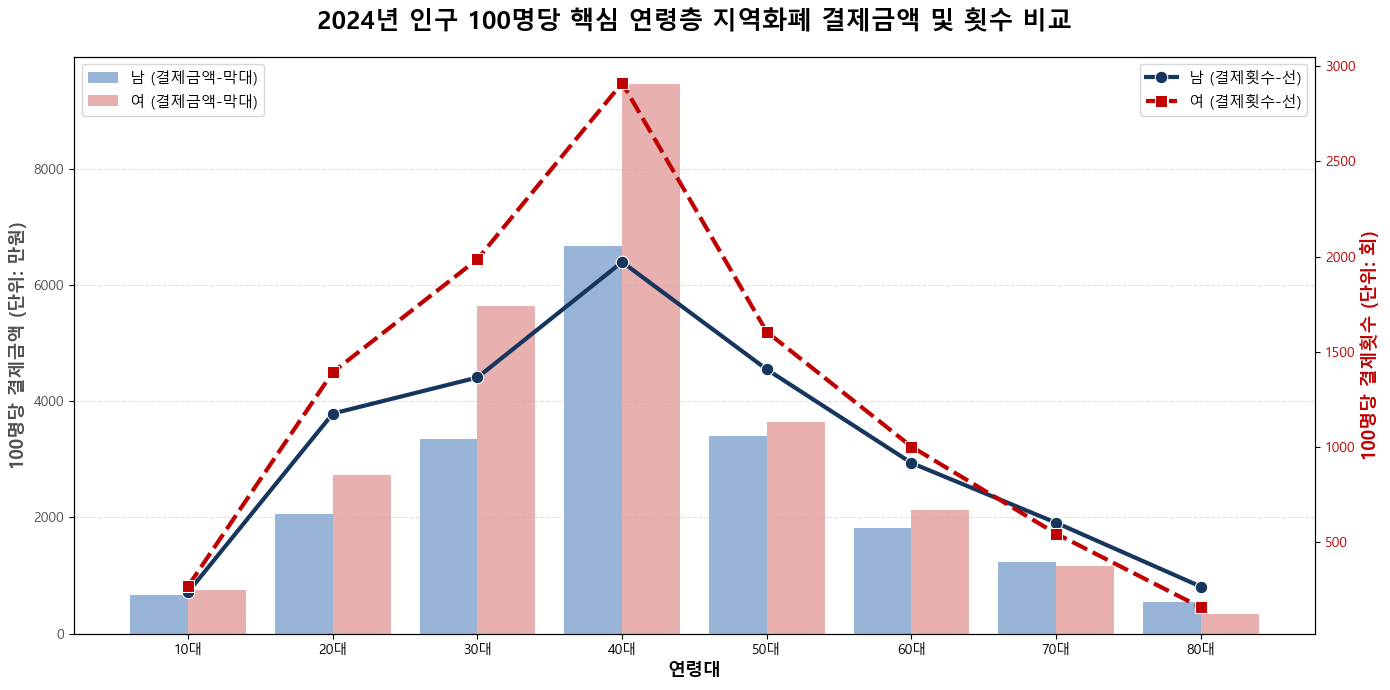

In [11]:


# ==========================================
# 5. 시각화 (이중 축 혼합 그래프)
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# 커스텀 색상 지정 (막대는 연하게, 선은 진하게)
bar_palette = {'남': '#8db4e2', '여': '#f2a6a6'}  # 연한 파랑, 연한 빨강
line_palette = {'남': '#17365d', '여': '#c00000'} # 짙은 남색, 짙은 빨강

# [Y축 1 - 막대그래프] 100명당 결제금액
sns.barplot(
    data=merged_df, 
    x='연령대_통합', 
    y='100명당_결제금액_만원', 
    hue='성별', 
    order=age_order, 
    palette=bar_palette,
    alpha=1,
    ax=ax1
)
ax1.set_ylabel('100명당 결제금액 (단위: 만원)', fontsize=13, fontweight='bold', color='#4f4f4f')
ax1.set_xlabel('연령대', fontsize=13, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4f4f4f')
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# [Y축 2 - 선그래프] 100명당 결제횟수
ax2 = ax1.twinx()
sns.lineplot(
    data=merged_df, 
    x='연령대_통합', 
    y='100명당_결제건수', 
    hue='성별', 
    style='성별', # 선 스타일(점선/실선)을 다르게 할 수 있음
    markers=['o', 's'], # 마커 모양 다르게 (동그라미, 네모)
    markersize=9,
    linewidth=3,   
    palette=line_palette,
    ax=ax2
)
ax2.set_ylabel('100명당 결제횟수 (단위: 회)', fontsize=13, fontweight='bold', color='#c00000')
ax2.tick_params(axis='y', labelcolor='#c00000')

# 그래프 제목
plt.title('2024년 인구 100명당 핵심 연령층 지역화폐 결제금액 및 횟수 비교', fontsize=18, fontweight='bold', pad=20)

# 범례 깔끔하게 분리
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1, [f"{l} (결제금액-막대)" for l in labels1], loc='upper left', fontsize=11, frameon=True)
ax2.legend(handles2, [f"{l} (결제횟수-선)" for l in labels2], loc='upper right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()